<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
!pip install seaborn

In [5]:
!pip install numpy

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [6]:
url= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'

### Step 2: Import necessary libraries and load the dataset


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the data


In [8]:
df = pd.read_csv(url)

### Display the first few rows of the data to understand its structure


In [9]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



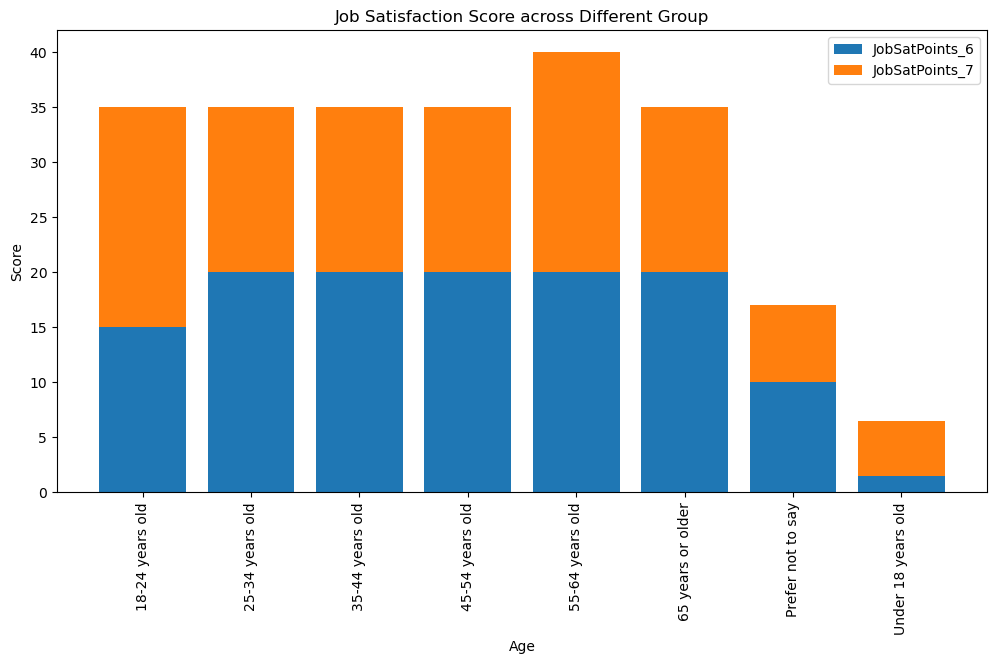

In [10]:
##Write your code here

median_6= df.groupby('Age')['JobSatPoints_6'].median()
median_7= df.groupby('Age')['JobSatPoints_7'].median()

ages=median_6.index

plt.figure(figsize=(12,6))
plt.bar(ages, median_6, label= 'JobSatPoints_6')
plt.bar(ages, median_7, bottom=median_6, label= 'JobSatPoints_7')
plt.title('Job Satisfaction Score across Different Group')
plt.legend()
plt.xticks(rotation=90)
plt.xlabel('Age')
plt.ylabel('Score')
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


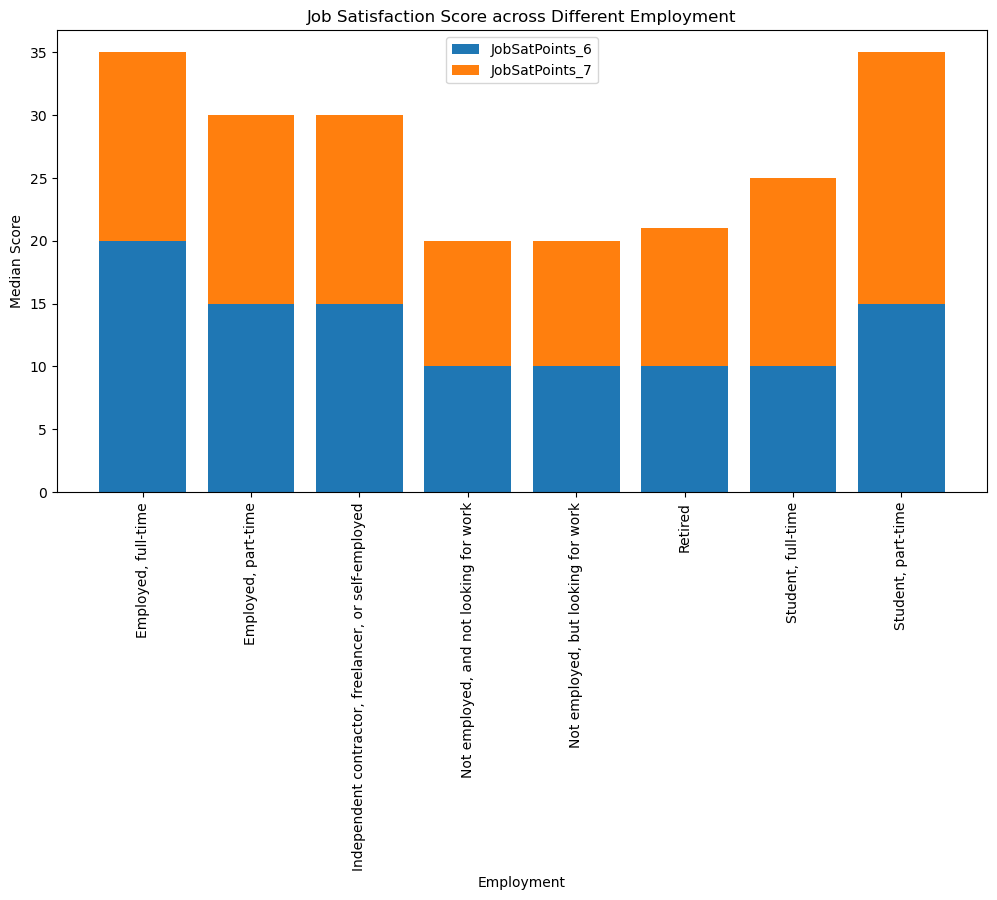

In [11]:
##Write your code here
#create a new df
df_emp= df[['Employment','JobSatPoints_6', 'JobSatPoints_7']].dropna().copy()

#split and explode
df_emp['Employment']= df_emp['Employment'].str.split(';')
df_emp= df_emp.explode('Employment')

#filter top 10 employment
top_10emp= df_emp['Employment'].value_counts().head(10).index
df_top10_emp= df_emp[df_emp['Employment'].isin(top_10emp)]


#median
median_6= df_top10_emp.groupby('Employment')['JobSatPoints_6'].median()
median_7= df_top10_emp.groupby('Employment')['JobSatPoints_7'].median()

x= median_6.index
#Visualization
plt.figure(figsize=(12,6))
plt.bar(x, median_6, label= 'JobSatPoints_6')
plt.bar(x, median_7, bottom=median_6, label= 'JobSatPoints_7')
plt.title('Job Satisfaction Score across Different Employment')
plt.legend()
plt.xticks(rotation=90)
plt.xlabel('Employment')
plt.ylabel('Median Score')
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


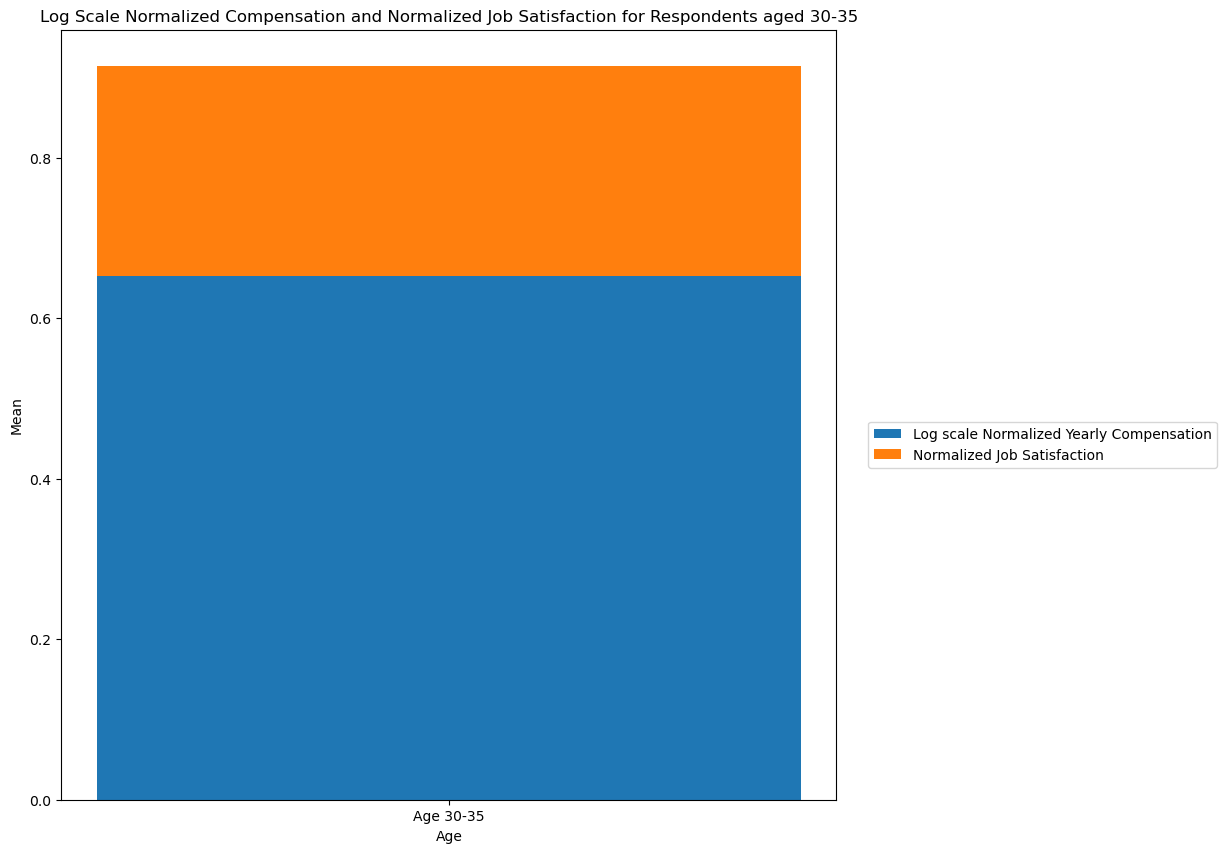

In [12]:
##Write your code here
#Filter age first
df_3035=df[df['Age']=='25-34 years old'][['ConvertedCompYearly','JobSatPoints_6']].dropna().copy()
df_3035['Log_ConvertedCompYearly']= np.log1p(df_3035['ConvertedCompYearly'])

#Normalization
comp_norm= df_3035['Log_ConvertedCompYearly'] / df_3035['Log_ConvertedCompYearly'].max()
sat_norm= df_3035['JobSatPoints_6'] / df_3035['JobSatPoints_6'].max()

#Mean
comp_mean= comp_norm.mean()
sat_mean= sat_norm.mean()

#Visualization
plt.figure(figsize=(10,10))
plt.bar('Age 30-35', comp_mean, label= 'Log scale Normalized Yearly Compensation')
plt.bar('Age 30-35', sat_mean, bottom= comp_mean, label= 'Normalized Job Satisfaction')
plt.title('Log Scale Normalized Compensation and Normalized Job Satisfaction for Respondents aged 30-35')
plt.legend(bbox_to_anchor=(1.5,0.5))
plt.xlabel('Age')
plt.ylabel('Mean')
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


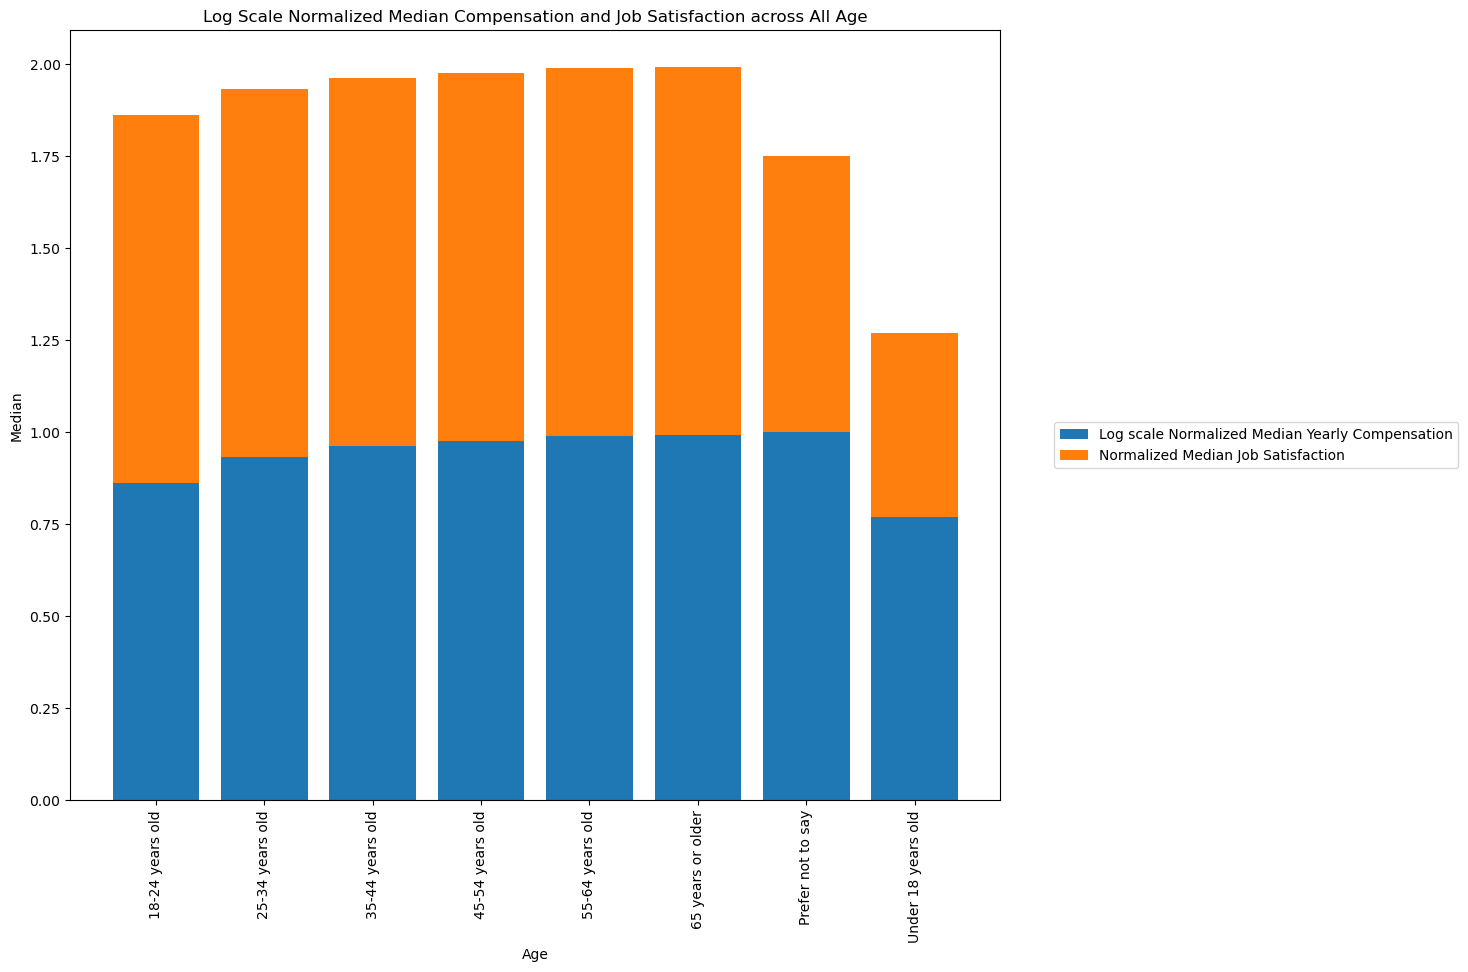

In [13]:
##Write your code here
#Create db
df_comp=df[['ConvertedCompYearly','JobSatPoints_6', 'Age']].dropna().copy()
df_comp['Log_ConvertedCompYearly']= np.log1p(df_comp['ConvertedCompYearly'])

#Group by
comp_median= df_comp.groupby('Age')['Log_ConvertedCompYearly'].median()
sat_median= df_comp.groupby('Age')['JobSatPoints_6'].median()

#Normalize
comp= comp_median/comp_median.max()
sat= sat_median/sat_median.max()

x=comp_median.index

#Visualization
plt.figure(figsize=(12,10))
plt.bar(x, comp, label= 'Log scale Normalized Median Yearly Compensation')
plt.bar(x, sat, bottom= comp, label= 'Normalized Median Job Satisfaction')
plt.title('Log Scale Normalized Median Compensation and Job Satisfaction across All Age')
plt.legend(bbox_to_anchor=(1.5,0.5))
plt.xlabel('Age')
plt.ylabel('Median')
plt.xticks(rotation=90)
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


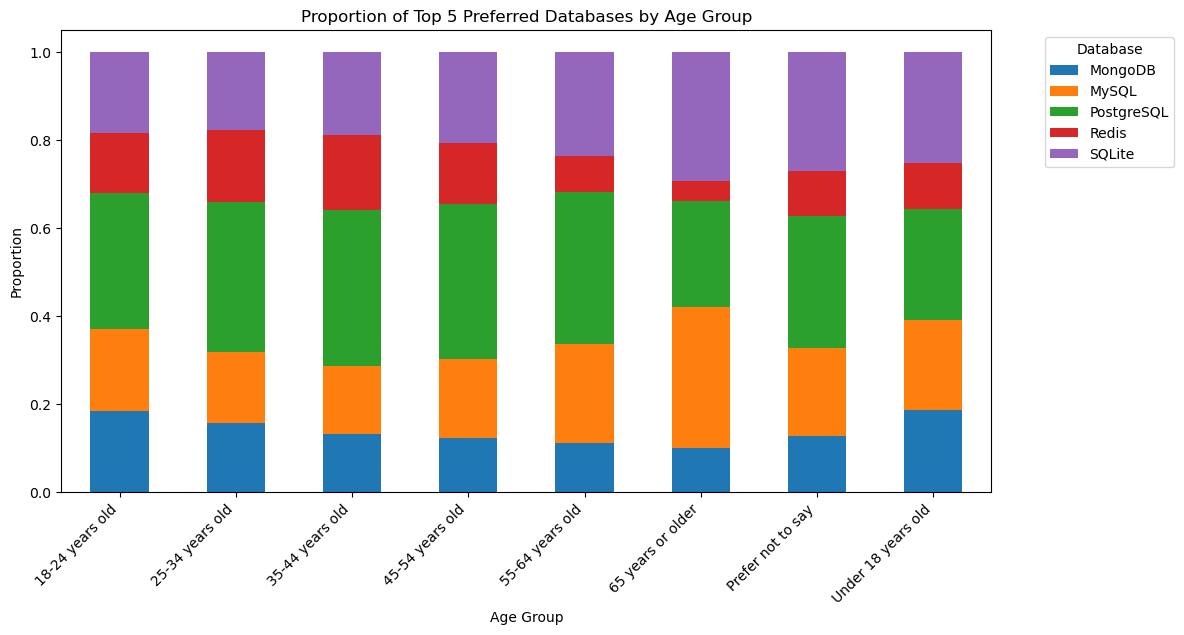

In [14]:
##Write your code here
#Create a db
df_database= df[['DatabaseWantToWorkWith', 'Age']].dropna().copy()
#Split
df_database['DatabaseWantToWorkWith'] = df_database['DatabaseWantToWorkWith'].str.split(';')
df_database=df_database.explode('DatabaseWantToWorkWith')
#Extract top 5 database and filter
top_5_database= df_database['DatabaseWantToWorkWith'].value_counts().head(5).index
df_database= df_database[df_database['DatabaseWantToWorkWith'].isin(top_5_database)]
#Create proportion table
df_age_pro= pd.crosstab(df_database['Age'], df_database['DatabaseWantToWorkWith'], normalize='index')

#Visualization
df_age_pro.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Proportion of Top 5 Preferred Databases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


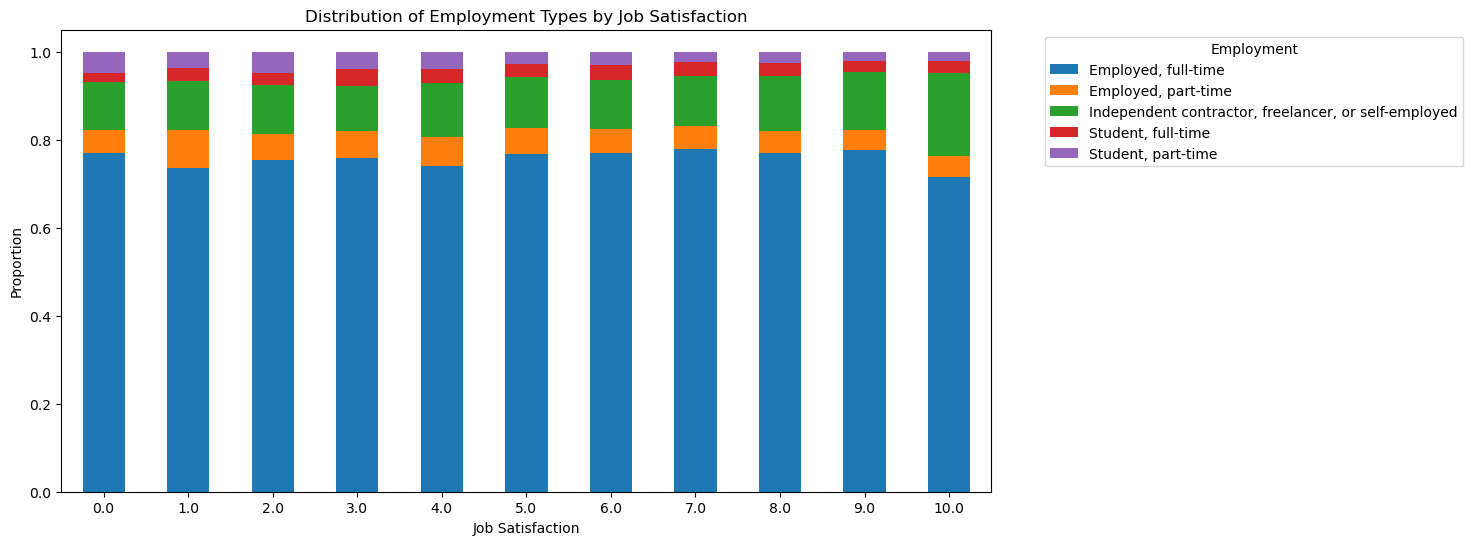

In [15]:
##Write your code here
df_emp_sat=df[['JobSat', 'Employment']].dropna().copy()
#split
df_emp_sat['Employment']= df_emp_sat['Employment'].str.split(';')
df_emp_sat= df_emp_sat.explode('Employment')

employment=df_emp_sat['Employment'].value_counts().head(5).index
df_top5_emp= df_emp_sat[df_emp_sat['Employment'].isin(employment)]

emp_sat= pd.crosstab(df_top5_emp['JobSat'], df_top5_emp['Employment'], normalize='index')

emp_sat.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Distribution of Employment Types by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Employment', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


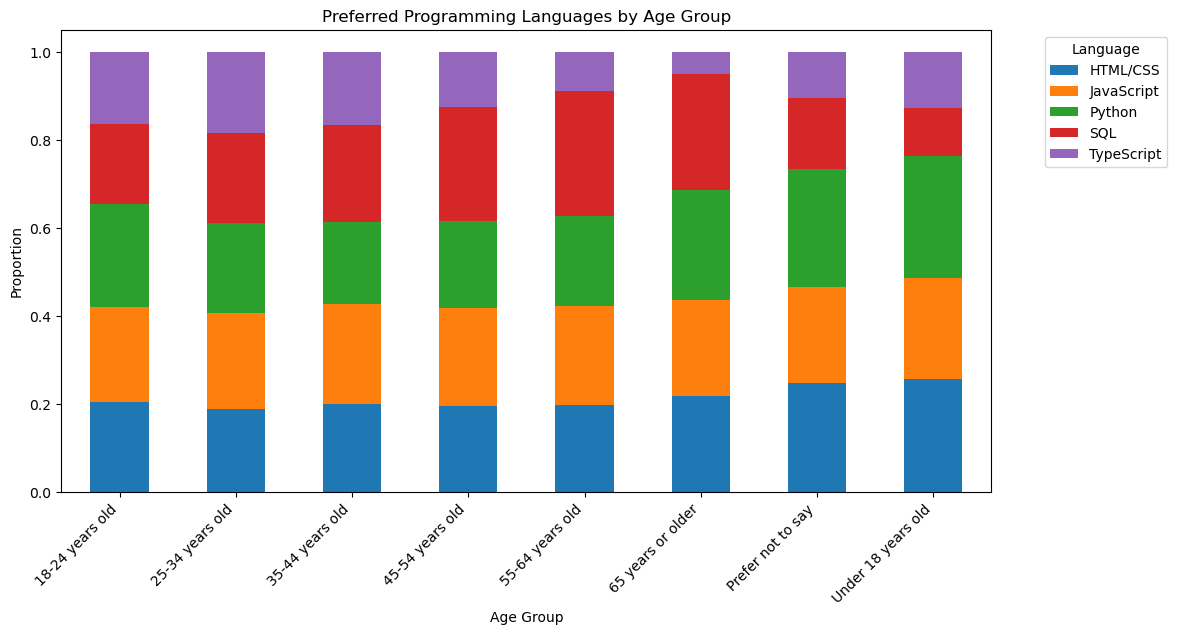

In [19]:
##Write your code here
#select columns
df_lang = df[['LanguageAdmired', 'Age']].dropna().copy()

#split + explode
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.split(';')
df_lang = df_lang.explode('LanguageAdmired')

#clean whitespace
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.strip()

#filter top 5 languages
top_lang = df_lang['LanguageAdmired'].value_counts().head(5).index
df_lang = df_lang[df_lang['LanguageAdmired'].isin(top_lang)]

#crosstab (proportion)
lang_age = pd.crosstab(
    df_lang['Age'],
    df_lang['LanguageAdmired'],
    normalize='index'
)

#plot stacked chart
lang_age.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Preferred Programming Languages by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Language', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


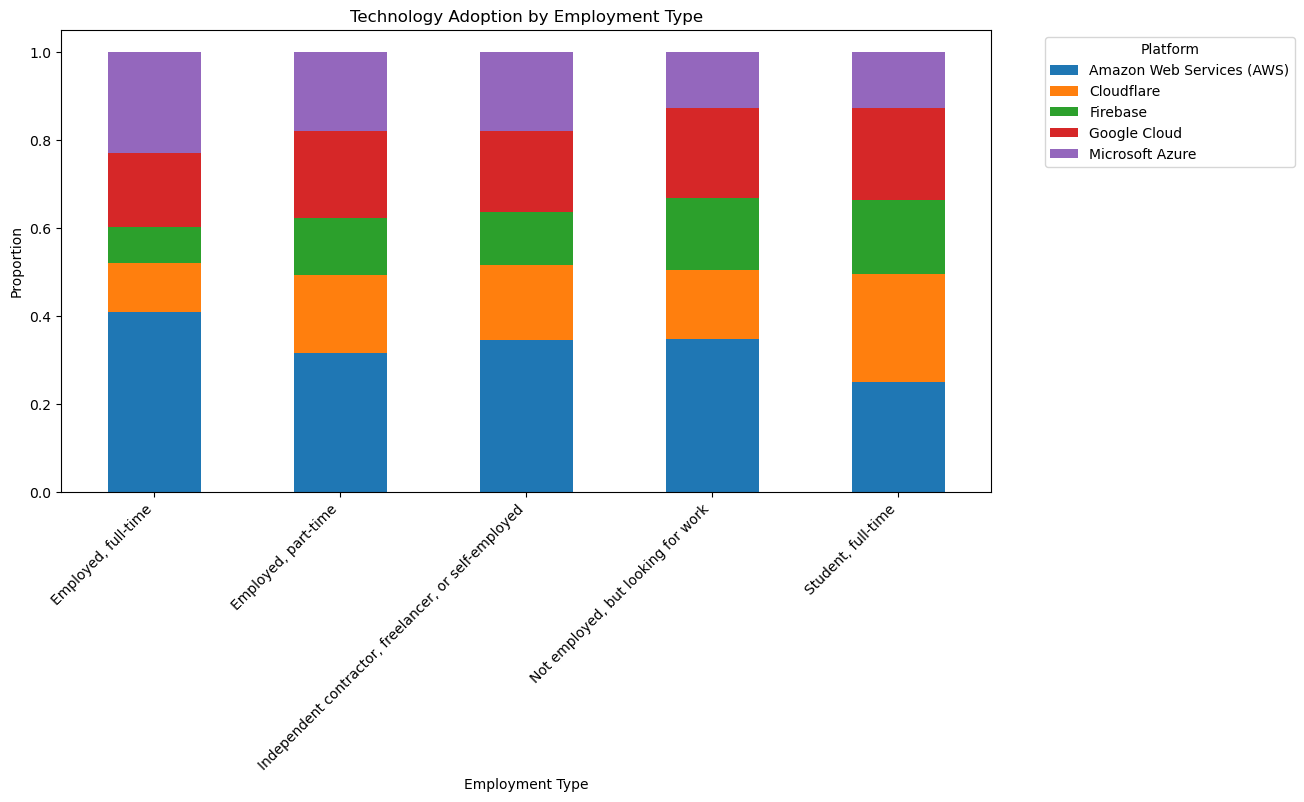

In [20]:
##Write your code here
#select columns
df_platform = df[['PlatformAdmired', 'Employment']].dropna().copy()

#split + explode
df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.split(';')
df_platform = df_platform.explode('PlatformAdmired')

df_platform['Employment'] = df_platform['Employment'].str.split(';')
df_platform = df_platform.explode('Employment')

# clean whitespace
df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.strip()
df_platform['Employment'] = df_platform['Employment'].str.strip()

#keep top 5 platforms and top 5 employment types
top_platform = df_platform['PlatformAdmired'].value_counts().head(5).index
top_employment = df_platform['Employment'].value_counts().head(5).index

df_platform = df_platform[
    df_platform['PlatformAdmired'].isin(top_platform) &
    df_platform['Employment'].isin(top_employment)
]

#proportion table
platform_emp = pd.crosstab(
    df_platform['Employment'],
    df_platform['PlatformAdmired'],
    normalize='index'
)

#plot stacked chart
platform_emp.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Technology Adoption by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
